<h2 style='color:blue' align="center">Decision Tree Classification</h2>

In [6]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [7]:
df = pd.read_csv("salaries.csv")
df.head()

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0


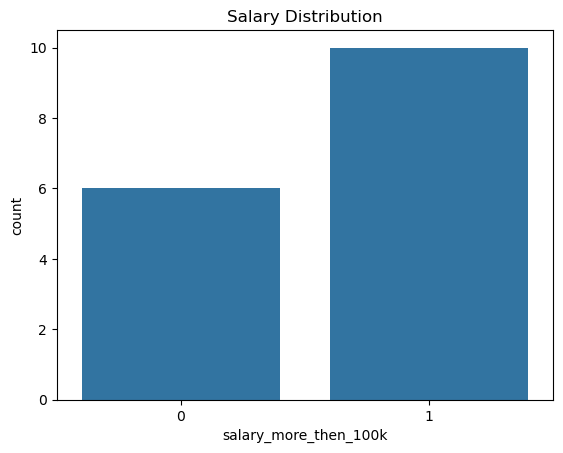

In [8]:
'''Since all your features are categorical, we won’t use line graphs — instead use:
Count plots
Bar charts
Heatmaps
'''
sns.countplot(x="salary_more_then_100k", data=df)
plt.title("Salary Distribution")
plt.show()

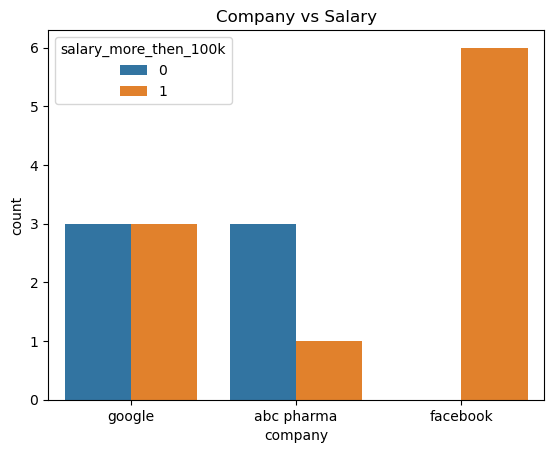

In [9]:
#Which company has more high earners?
sns.countplot(x="company", hue="salary_more_then_100k", data=df)
plt.title("Company vs Salary")
plt.show()

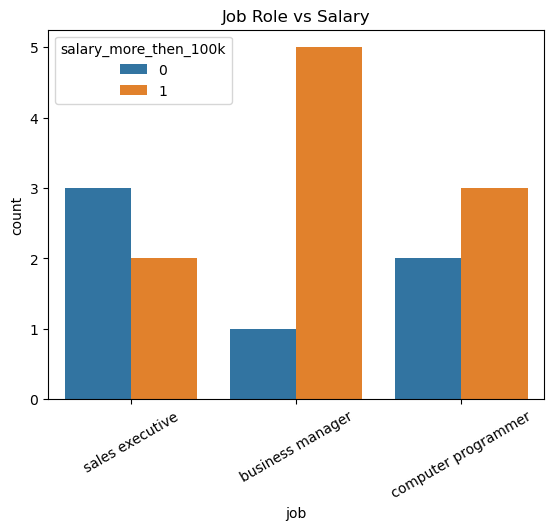

In [10]:
# which job roles earn more
sns.countplot(x="job", hue="salary_more_then_100k", data=df)
plt.xticks(rotation=30)
plt.title("Job Role vs Salary")
plt.show()

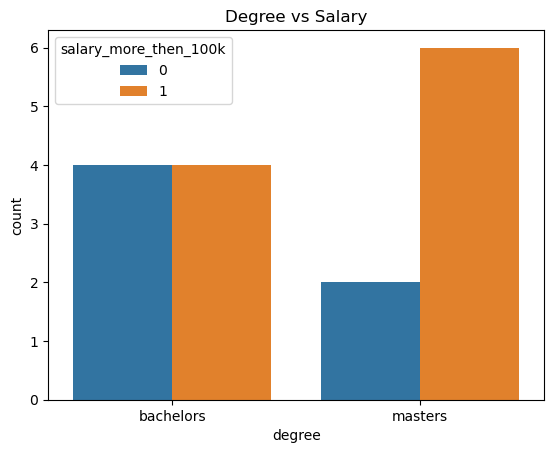

In [11]:
# Does Masters → higher salary?
sns.countplot(x="degree", hue="salary_more_then_100k", data=df)
plt.title("Degree vs Salary")
plt.show()

In [13]:
inputs = df.drop('salary_more_then_100k',axis='columns')

In [14]:
target = df['salary_more_then_100k']

In [30]:
from sklearn.preprocessing import LabelEncoder
le_company = LabelEncoder()
le_job = LabelEncoder()
le_degree = LabelEncoder()

In [28]:
inputs['company_n'] = le_company.fit_transform(inputs['company'])
inputs['job_n'] = le_job.fit_transform(inputs['job'])
inputs['degree_n'] = le_degree.fit_transform(inputs['degree'])
print(le_company.classes_)
print(le_job.classes_)
print(le_degree.classes_)

['abc pharma' 'facebook' 'google']
['business manager' 'computer programmer' 'sales executive']
['bachelors' 'masters']


In [17]:
inputs

,company,job,degree,company_n,job_n,degree_n
0,google,sales executive,bachelors,2,2,0
1,google,sales executive,masters,2,2,1
2,google,business manager,bachelors,2,0,0
3,google,business manager,masters,2,0,1
4,google,computer programmer,bachelors,2,1,0
5,google,computer programmer,masters,2,1,1
6,abc pharma,sales executive,masters,0,2,1
7,abc pharma,computer programmer,bachelors,0,1,0
8,abc pharma,business manager,bachelors,0,0,0
9,abc pharma,business manager,masters,0,0,1


In [18]:
inputs_n = inputs.drop(['company','job','degree'],axis='columns')

In [19]:
inputs_n

,company_n,job_n,degree_n
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0
5,2,1,1
6,0,2,1
7,0,1,0
8,0,0,0
9,0,0,1


In [20]:
target

0     0
1     0
2     1
3     1
4     0
5     1
6     0
7     0
8     0
9     1
10    1
11    1
12    1
13    1
14    1
15    1
Name: salary_more_then_100k, dtype: int64

In [21]:
from sklearn import tree
model = tree.DecisionTreeClassifier()

In [22]:
model.fit(inputs_n, target)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
model.score(inputs_n,target)

1.0

**Is salary of Google, Computer Engineer, Bachelors degree > 100 k ?**

In [24]:
import pandas as pd

test = pd.DataFrame([{
    'company_n': 2,
    'job_n': 1,
    'degree_n': 0
}])
model.predict(test)
#model.predict([[2,1,0]])

array([0])

**Is salary of Google, Computer Engineer, Masters degree > 100 k ?**

In [25]:
test = pd.DataFrame([{
    'company_n': 2,
    'job_n': 1,
    'degree_n': 1
}])
model.predict(test)
# model.predict([[2,1,1]])

array([1])

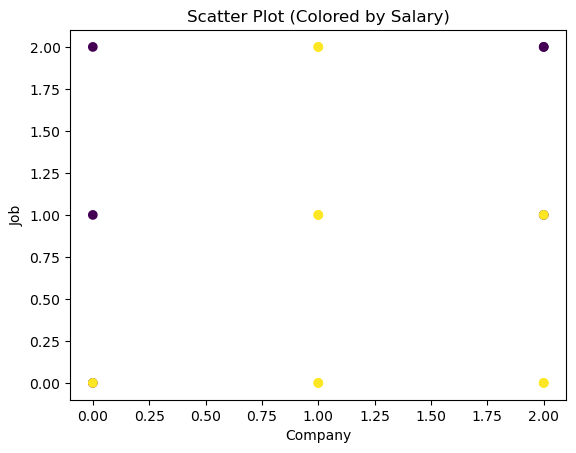

In [32]:
import matplotlib.pyplot as plt

plt.scatter(
    df_encoded['company'],
    df_encoded['job'],
    c=df_encoded['salary_more_then_100k']
)

plt.xlabel("Company")
plt.ylabel("Job")
plt.title("Scatter Plot (Colored by Salary)")
plt.show()

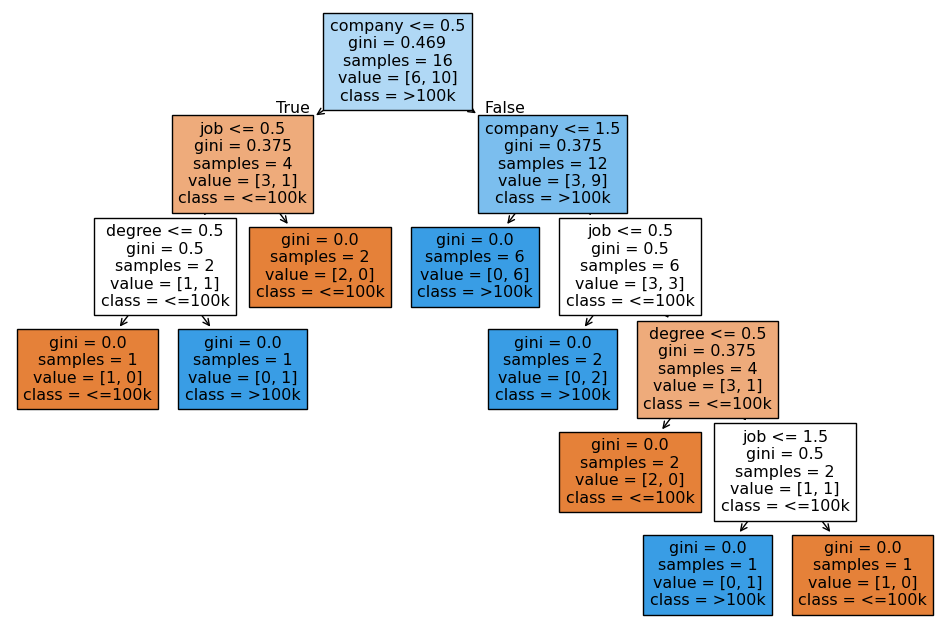

In [31]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plot_tree(
    model,
    feature_names=['company', 'job', 'degree'],
    class_names=['<=100k', '>100k'],
    filled=True
)

plt.show()

# Understanding Each Node in the Decision Tree

Each box in the tree shows the following information:

**Example node:**

```
company <= 1.5
gini = 0.48
samples = 16
value = [6, 10]
```

| Field | Meaning |
| --- | --- |
| `company <= 1.5` | The condition being tested at this split |
| `gini` | Impurity at this node — lower is better |
| `samples` | Number of rows reaching this node |
| `value` | Count of each class — `[low_salary, high_salary]` |

---

# What You Will Observe (from Your Dataset)

The tree will likely learn the following rules:

## Rule 1

If `company = facebook` → High salary

## Rule 2

If `company = google`:

- Business manager → High salary
- Others → Depends on degree

## Rule 3

If `company = abc pharma`:

- Mostly low salary

---

# Why This is Powerful

You can read the model's decisions like plain English:

```
IF company = facebook       → salary = high
ELSE IF job = business manager  → salary = high
ELSE                        → salary = low
```

> The model is making decisions the same way a human would — one condition at a time.

# Step 0: Your Target Distribution [ Entropy explained ]

Column: `salary_more_then_100k`

| Class | Count |
| --- | --- |
| 1 (High salary) | 10 |
| 0 (Low salary) | 6 |
| **Total** | **16** |

---

# Step 1: Calculate Initial Entropy (Before Split)

## Probabilities

```
p(1) = 10/16 = 0.625
p(0) = 6/16  = 0.375
```

## Formula

```
Entropy = - p(1) * log2(p(1)) - p(0) * log2(p(0))
```

## Calculation

```
Entropy = - (0.625 * log2(0.625)) - (0.375 * log2(0.375))
         = - (0.625 * -0.678) - (0.375 * -1.415)
         = 0.954
```

## Interpretation

- Initial entropy = **0.954**
- The data is quite mixed — not pure
- A split is needed to reduce this uncertainty

---

# Step 2: Try Splitting by `company`

We evaluate entropy for each company separately.

---

## Google

Data:

```
[0, 0, 1, 1, 0, 1]
```

| Class | Count |
| --- | --- |
| 1 | 3 |
| 0 | 3 |

Probabilities: `p(1) = 0.5`, `p(0) = 0.5`

```
Entropy = 1.0  (maximum — completely mixed)
```

---

## ABC Pharma

Data:

```
[0, 0, 0, 1]
```

| Class | Count |
| --- | --- |
| 1 | 1 |
| 0 | 3 |

Probabilities: `p(1) = 0.25`, `p(0) = 0.75`

```
Entropy = 0.81
```

---

## Facebook

Data:

```
[1, 1, 1, 1, 1, 1]
```

All samples belong to class 1.

```
Entropy = 0.0  (perfectly pure)
```

---

# Step 3: Weighted Entropy After Split

Total samples = 16

## Formula

```
Weighted Entropy = (6/16)*1.0 + (4/16)*0.81 + (6/16)*0.0
```

## Calculation

```
= 0.375 + 0.2025 + 0
= 0.5775
```

---

# Step 4: Information Gain

```
Information Gain = Initial Entropy - Weighted Entropy
                 = 0.954 - 0.5775
                 = 0.376
```

## Interpretation

Splitting by `company`:

- Reduced entropy from **0.954** to **0.578** — a significant improvement
- Facebook became perfectly pure (entropy = 0)
- The first rule the tree learns:

```
IF company = facebook → salary = 1
```

This split is chosen because it gives the **maximum reduction in uncertainty**.

---

# Step 5: What Happens Next?

The tree now focuses on the remaining impure branches:

| Branch | Entropy | Status |
| --- | --- | --- |
| Facebook | 0.0 | Done — pure |
| ABC Pharma | 0.81 | Almost pure |
| Google | 1.0 | Needs further splitting |

The tree will try splitting the Google subset further using `job` and `degree`.

---

## Summary So Far

| Step | Entropy |
| --- | --- |
| Before split | 0.954 |
| After split by `company` | 0.578 |
| Information Gain | 0.376 |

---

# Focus: Google Subset

## Data

| job | degree | salary |
| --- | --- | --- |
| sales executive | bachelors | 0 |
| sales executive | masters | 0 |
| business manager | bachelors | 1 |
| business manager | masters | 1 |
| computer programmer | bachelors | 0 |
| computer programmer | masters | 1 |

Target distribution: `1 → 3`, `0 → 3`

```
Entropy = 1.0  (maximum — completely mixed)
```

---

# Try Split 1: `job`

## Sales Executive

```
[0, 0]
```

```
Entropy = 0.0  (pure)
```

## Business Manager

```
[1, 1]
```

```
Entropy = 0.0  (pure)
```

## Computer Programmer

```
[0, 1]
```

```
Entropy = 1.0  (still mixed)
```

## Weighted Entropy

```
= (2/6)*0.0 + (2/6)*0.0 + (2/6)*1.0
= 0 + 0 + 0.333
= 0.333
```

---

# Try Split 2: `degree`

## Bachelors

```
[0, 1, 0]   (1 one, 2 zeros)
```

```
Entropy = 0.918
```

## Masters

```
[0, 1, 1]   (2 ones, 1 zero)
```

```
Entropy = 0.918
```

## Weighted Entropy

```
= (3/6)*0.918 + (3/6)*0.918
= 0.918
```

---

# Comparing Both Splits

| Feature | Entropy After Split | Result |
| --- | --- | --- |
| `job` | 0.333 | Winner |
| `degree` | 0.918 | Worse |

**Winner: `job`** — it reduces entropy the most.

---

# Updated Tree So Far

```
            company
           /   |    \
       google  abc   facebook
         |
        job
      /   |      \
   sales   bm    cp
     0      1     ?
```

---

# Final Split: Computer Programmer (Google)

Remaining impure branch:

```
[0, 1]   Entropy = 1.0
```

Split by `degree`:

```
Bachelors → 0
Masters   → 1
```

Perfect split — entropy = 0 on both sides.

---

# Final Decision Tree (Human Readable)

```
IF company = facebook → salary = 1

ELSE IF company = abc pharma:
    IF job = business manager AND degree = masters → 1
    ELSE → 0

ELSE IF company = google:
    IF job = business manager → 1
    ELSE IF job = sales executive → 0
    ELSE IF job = computer programmer:
        IF degree = masters → 1
        ELSE → 0
```

---

# Key Learning

The tree builds rules the same way a human would:

1. First split on the biggest separator: `company`
2. Refine the impure branch with: `job`
3. Final cleanup with: `degree`

---

# Why This is Powerful

You have just manually built a Decision Tree using **Entropy** and **Information Gain** — the same logic scikit-learn uses internally.

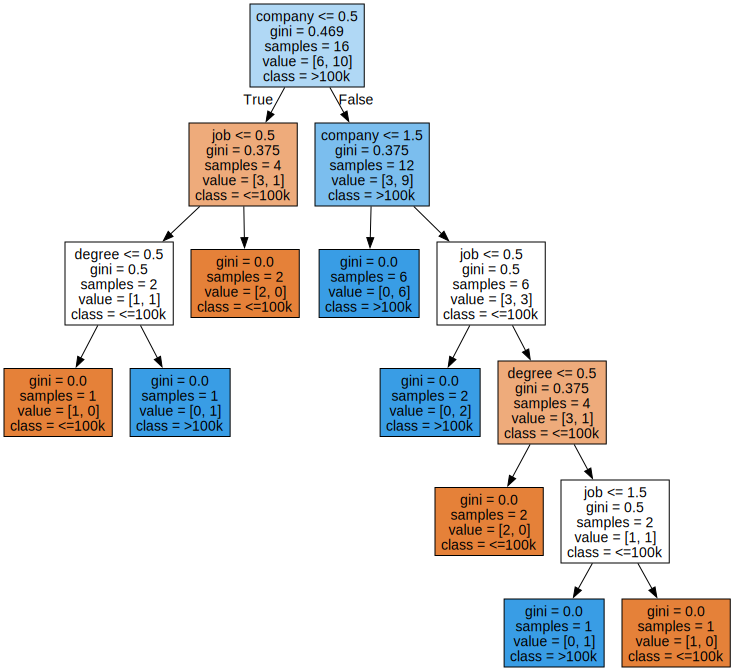

In [26]:
# First, install the graphviz package
!pip install graphviz
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=['company','job','degree'],
    class_names=['<=100k','>100k'],
    filled=True
)

graph = graphviz.Source(dot_data)
graph

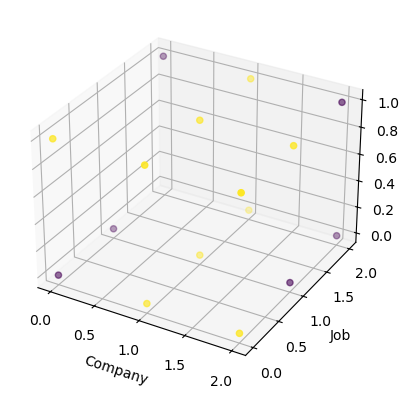

In [29]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_encoded['company'],
    df_encoded['job'],
    df_encoded['degree'],
    c=df_encoded['salary_more_then_100k']
)

ax.set_xlabel("Company")
ax.set_ylabel("Job")
ax.set_zlabel("Degree")

plt.show()

**Exercise: Build decision tree model to predict survival based on certain parameters**

<img src="titanic.jpg" height=200 width=400/>

CSV file is available to download at https://github.com/codebasics/py/blob/master/ML/9_decision_tree/Exercise/titanic.csv

##### In this file using following columns build a model to predict if person would survive or not,

1. Pclass
1. Sex
1. Age
1. Fare

##### Calculate score of your model